# BANKING77 EDA

Before training any model, we first get to know the data. This notebook checks the split sizes, label coverage, missing values, duplicate queries, and typical query length. The official test set stays untouched throughout.

## How to run this notebook

- Use the `nlp-banking` Conda environment.
- Run the cells from top to bottom.
- The first data-loading cell may download BANKING77 from Hugging Face.
- The observations and figures produced here are the evidence used by the later experiments and report.

## Why this step matters

The other example notebook uses EDA to justify a causal language-model objective. Here, EDA serves a different purpose: it confirms that BANKING77 is a balanced 77-intent classification problem and helps us anticipate confusing intent pairs before evaluating models.

## Reproducibility

The validation split is created from the original training split with seed `42`. The official test split is not used for model selection.

## Course connection

This follows the course emphasis on understanding the dataset before selecting a model. The classification-oriented Transformer notebook in `references/course/Transformers_classification.ipynb` is the closest course example for this task.

## Step 1 — Load and split BANKING77

**What this does:** loads the public dataset and creates a reproducible validation split.

**Why:** the validation set is used during development, while the official test set must remain untouched until final evaluation.


In [1]:
# Load the dataset once so every later notebook uses the same split.
# The validation split comes from training data; the official test data is preserved.
# Add the repository root so the notebook can import reusable project code.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from src.data.load_data import load_banking77
dataset = load_banking77(validation_size=0.1, seed=42)
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9002
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1001
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})

## Step 2 — Check data quality

**What this does:** checks split sizes, labels, missing values, and duplicate queries.

**Why:** these checks tell us whether the data is safe to use and whether a model might be affected by duplicate examples or missing fields.


In [2]:
# Convert the splits to pandas because descriptive statistics and plots are easier to read there.
# We inspect every split size and verify that text and labels are complete.
# Convert the dataset to pandas only for the descriptive checks and plots.
import pandas as pd
train = dataset["train"].to_pandas()
validation = dataset["validation"].to_pandas()
test = dataset["test"].to_pandas()
print({"train": len(train), "validation": len(validation), "test": len(test), "labels": train["label"].nunique()})
print("missing:", train.isna().sum().to_dict())
print("duplicates:", int(train["text"].duplicated().sum()))

{'train': 9002, 'validation': 1001, 'test': 3080, 'labels': 77}
missing: {'text': 0, 'label': 0}
duplicates: 0


## Step 3 — Create useful EDA figures

**What this does:** saves the class distribution and query-length figures used in the report.

**Why:** class balance and text length affect model difficulty, memory use, and interpretation of errors.


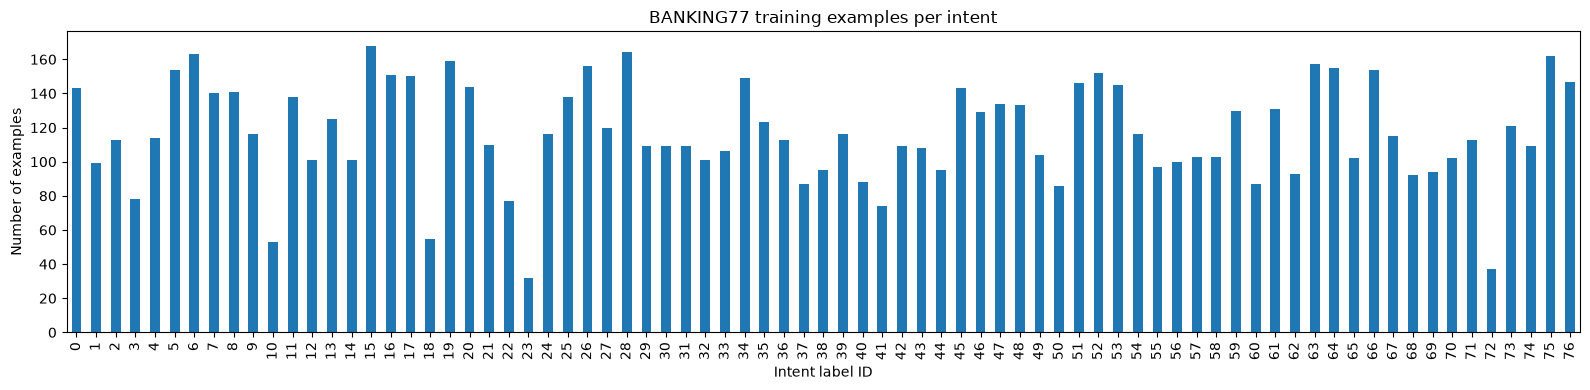

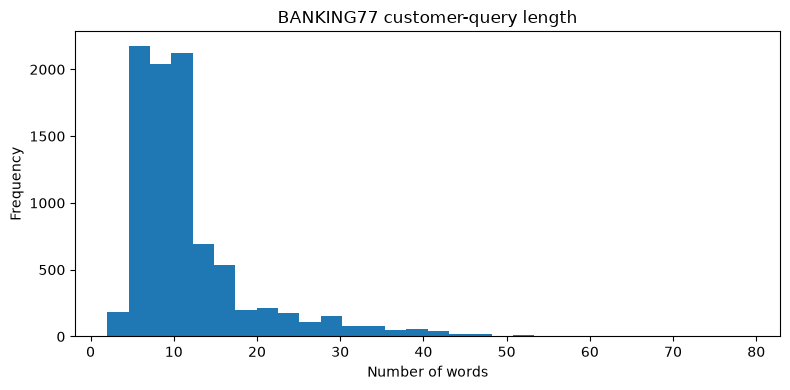

In [3]:
# Save the two figures used in the report so the visual evidence travels with the notebook.
# Label counts show class balance; word lengths show how short or long the queries are.
# Save the two plots used in the report: label balance and query length.
import matplotlib.pyplot as plt

figures_dir = Path.cwd().parent / "figures"
figures_dir.mkdir(exist_ok=True)

train["word_length"] = train["text"].str.split().str.len()

ax = train["label"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(16, 4),
    title="BANKING77 training examples per intent",
)
ax.set_xlabel("Intent label ID")
ax.set_ylabel("Number of examples")
plt.tight_layout()
plt.savefig(figures_dir / "class_distribution.png", dpi=150)
plt.show()
plt.close()

ax = train["word_length"].plot(
    kind="hist",
    bins=30,
    figsize=(8, 4),
    title="BANKING77 customer-query length",
)
ax.set_xlabel("Number of words")
plt.tight_layout()
plt.savefig(figures_dir / "text_length_distribution.png", dpi=150)
plt.show()
plt.close()